In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
file_path = r"..\data\gold\olist_"
gold_orders = pd.read_parquet(file_path + "orders.parquet")
gold_products = pd.read_parquet(file_path + "products.parquet")
gold_customers = pd.read_parquet(file_path + "customers.parquet")
silver_payment =  pd.read_parquet(r"..\data\silver\olist_order_payments_dataset.parquet")

# Payment Analysis

## Objective

The objective of this analysis is to understand how customers pay for their
orders and whether payment behaviour is associated with order value,
installments, customer experience, and other business outcomes.

## Business Questions

1. Which payment methods are used most frequently?
2. Which payment methods generate the most revenue?
3. How important are installment payments in the marketplace?
4. Does order value increase with the number of installments?
5. Which payment methods are associated with the highest transaction values?
6. Are installment behaviours different across payment methods?
7. Do payment behaviours vary geographically?
8. Is payment behaviour associated with review scores or delivery performance?
9. Can we identify meaningful payment behaviour segments?

In [186]:
palette="PiYG",


In [13]:
plt.style.use('dark_background')

### 1. Which payment methods are used most frequently?

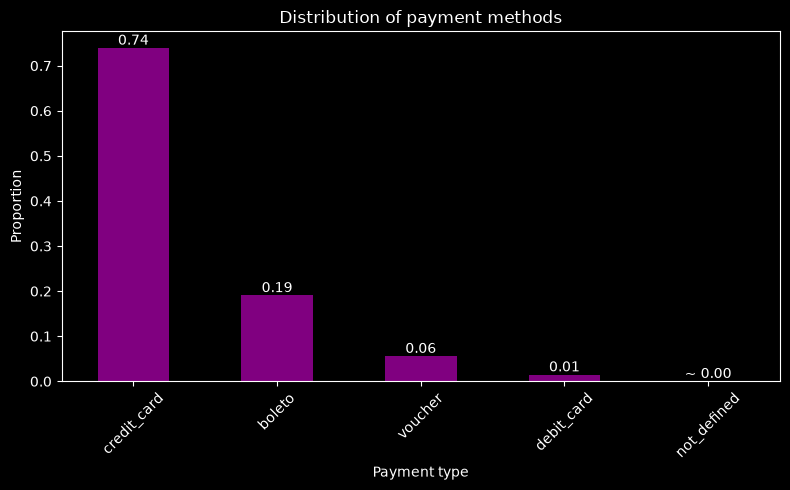

In [30]:
payment_type_prop = silver_payment["payment_type"].value_counts(normalize=True)

ax = payment_type_prop.plot(kind="bar", color="purple", figsize=(8, 5))

for i, value in enumerate(payment_type_prop):
    if i == len(payment_type_prop) - 1:
        label = " ~ 0.00 "
    else:
        label = f"{value:.2f}"

    plt.text(i, value, label, ha="center", va="bottom")

plt.ylabel("Proportion")
plt.xlabel("Payment type")
plt.title("Distribution of payment methods")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [189]:
payment_method_summary = (
    silver_payment.groupby("payment_type")
    .agg(
        transactions=("order_id", "count"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean"),
        median_payment_value=("payment_value", "median"),
    )
    .reset_index()
)

payment_method_summary["transaction_share"] = (
    payment_method_summary["transactions"]
    / payment_method_summary["transactions"].sum()
)

payment_method_summary["revenue_share"] = (
    payment_method_summary["total_payment_value"]
    / payment_method_summary["total_payment_value"].sum()
)

payment_method_summary.sort_values("total_payment_value", ascending=False)


,payment_type,transactions,total_payment_value,avg_payment_value,median_payment_value,transaction_share,revenue_share
1,credit_card,76795,12542084.19,163.319021,106.87,0.739224,0.783446
0,boleto,19784,2869361.27,145.034435,93.89,0.190440,0.179236
4,voucher,5775,379436.87,65.703354,39.28,0.055590,0.023702
2,debit_card,1529,217989.79,142.570170,89.30,0.014718,0.013617
3,not_defined,3,0.00,0.000000,0.00,0.000029,0.000000


In [193]:
silver_payment.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'dq_zero_payment',
       'payment_installments_cat', 'installment_group'],
      dtype='str')

In [207]:
silver_payment["installment_group"] = pd.cut(
    silver_payment["payment_installments"],
    bins=[0, 1, 3, 5, np.inf],
    labels=["1", "2-3", "4-5", "6+"],
)

installment_summary =(
    silver_payment.groupby("installment_group").agg(
        transactions=("order_id", "count"),
        total_payment_values=("payment_value", "sum"),
        avg_payment_values=("payment_value", "mean"),
        median_payment_values=("payment_value", "median"),
    )
)

installment_summary["transaction_share (%)"] = (
    100
    * installment_summary["transactions"]
    / installment_summary["transactions"].sum()
)
installment_summary["payments_share (%)"] = (
    100
    * installment_summary["total_payment_values"]
    / installment_summary["total_payment_values"].sum()
)

installment_summary

,transactions,total_payment_values,avg_payment_values,median_payment_values,transaction_share (%),payments_share (%)
installment_group,,,,,,
1,52546,5907233.36,112.420229,73.340,50.581418,36.900182
2-3,22874,3070386.83,134.230429,109.725,22.018790,19.179509
4-5,12337,2125081.91,172.252728,120.490,11.875746,13.274558
6+,16127,4905981.39,304.209177,188.320,15.524046,30.645752


In [208]:
# silver_payment["payment_installments_cat"] = np.where(
#     silver_payment["payment_installments"] >= 6,
#     "6+",
#     silver_payment["payment_installments"].astype(str)
# )

# installment_counts = (
#     silver_payment["payment_installments_cat"]
#     .value_counts()
#     # .reindex(["1.0", "2.0", "3.0", "4.0", "5.0", "6+"])
# )

# installment_counts.plot(kind="barh" , color ="purple")
# for i , value in enumerate(installment_counts):
#     if i != 0 :
#         plt.text(
#         x=value + 1000,
#         y=i, 
#         s=f"{value} ({value / len(silver_payment) * 100:.2f} %)"
#         )
#     else :
#         plt.text(
#             x=value - 15000,
#             y=i,
#             s=f"{value} ({value / len(silver_payment) * 100:.2f} %)",
#             color="black"
#         )

# plt.title("Distribution of Payment Installments")
# plt.xlabel("Number of Payments")
# plt.ylabel("Installments")
# plt.show()

Single-payment transactions dominate the dataset, accounting for 50.58% of all payments. The proportion gradually decreases for 2 to 5 installments, while transactions with 6 or more installments still represent 15.52%. This suggests that most customers prefer to pay in a single installment, although longer payment plans remain an important purchasing option.

In [215]:
palette = "PiYG"

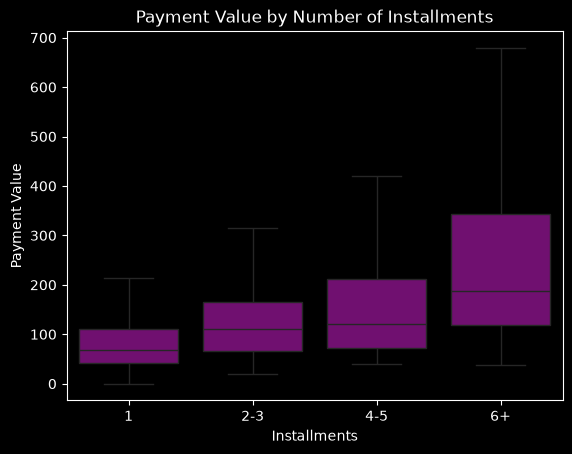

In [228]:
sns.boxplot(
    data=silver_payment.query("payment_type == 'credit_card'"),
    x="installment_group",
    y="payment_value",
    showfliers=False,
    color="purple"
    # hue="installment_group",
    # palette =palette
)

plt.title("Payment Value by Number of Installments")
plt.xlabel("Installments")
plt.ylabel("Payment Value")
plt.show()


Payment value tends to increase with the number of installments. Single-payment transactions have the lowest median payment value, while purchases with 6 or more installments show a substantially higher median and a wider distribution. This suggests that customers are more likely to use installment plans for higher-value purchases.

In [221]:
credit_payments = silver_payment.query("payment_type == 'credit_card'").copy()


In [222]:
installment_value_analysis = (
    credit_payments.groupby("installment_group", observed=True)
    .agg(
        transactions=("order_id", "count"),
        avg_payment_value=("payment_value", "mean"),
        median_payment_value=("payment_value", "median"),
        total_payment_value=("payment_value", "sum"),
    )
    .reset_index()
)

installment_value_analysis


,installment_group,transactions,avg_payment_value,median_payment_value,total_payment_value
0,1,25455,95.872930,67.870,2440445.43
1,2-3,22874,134.230429,109.725,3070386.83
2,4-5,12337,172.252728,120.490,2125081.91
3,6+,16127,304.209177,188.320,4905981.39


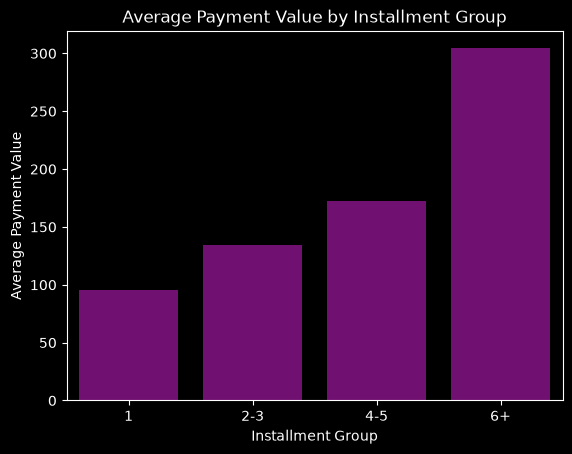

In [229]:
sns.barplot(
    data=installment_value_analysis,
    x="installment_group",
    y="avg_payment_value",
    color="purple"
)

plt.title("Average Payment Value by Installment Group")
plt.xlabel("Installment Group")
plt.ylabel("Average Payment Value")
plt.show()


As installment duration increase , average payement value tends to increase , suggesting that customers primarily use installment plans for higher-value purchases. 

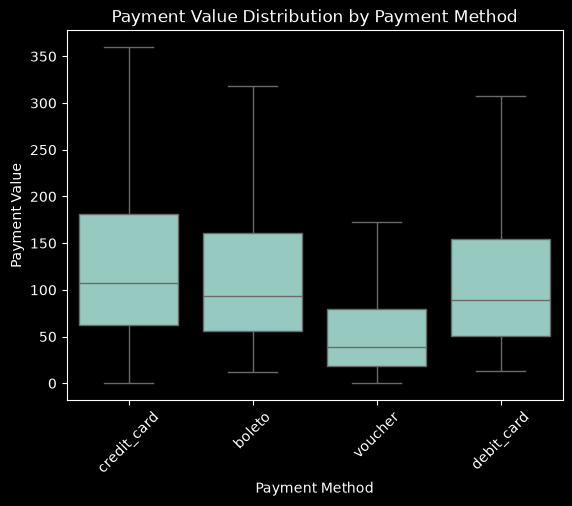

In [230]:
sns.boxplot(
    data=silver_payment.query(
        "payment_type != 'not_defined'"
    ),
    x="payment_type",
    y="payment_value",
    showfliers=False
)

plt.xticks(rotation=45)
plt.title("Payment Value Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Payment Value")
plt.show()